## DINOv2 LSTM ##

In [ ]:
import os
import cv2
import torch
import numpy as np
from tqdm import tqdm

from PIL import Image
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix


import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, models, transforms
from torch.utils.data import Dataset, DataLoader


import os
import pickle
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from PIL import Image

import classsification.lstm.common_functions_python as common_functions_python


ModuleNotFoundError: No module named 'common_functions'

In [ ]:
import sys
import importlib # !pip install importlib
sys.path.append('.')
import classsification.lstm.common_functions_python as common_functions_python
importlib.reload(common_functions_python)

print(common_functions_python.greetFromAnotherFile(name))

## Device

In [39]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
# device = torch.device("cpu")
print('device: ', device)

device:  cuda


In [40]:
config_file = {
                'name': 'DINO_left_hand',
                'datasets': ['dino_left_small'],
                'bidirectional_lstm': False,
                'lstm_dropout': 0.2,
                'mlp_dropout': 0.2,
                'lr': 0.0002,
                'step_size': 10,
                'gamma': 0.5,
                'weight_decay': 0,
                'hidden_dim': 256,
                'num_layers': 2,
                'batch_size': 1,
                'frame_frequency': 3,
                'num_epoch': 2
                }

## Prepare Dataset

In [41]:
# pose_pickle_folder = '/media/osero/SamsungSSD/CMPE_SSD/mmpose-full/0001/User_2_001.pickle'
pose_pickle_folder = '/media/osero/SamsungSSD/CMPE_SSD/mmpose-full/'

def get_active_frames_from_pickle(input_raw) -> np.ndarray:
    threshold = (
        (((input_raw["pose"]["left_hip"][:, 1] + input_raw["pose"]["right_hip"][:, 1]) / 2 )* 7)
        + input_raw["pose"]["nose"][:, 1] * 3
    ) / 10

    active_frames = (
        np.minimum(
            input_raw["hand_left"]["left_lunate_bone"][:, 1],
            input_raw["hand_right"]["right_lunate_bone"][:, 1],
        )
        < threshold
    )

    active_frame_indices = np.argwhere(active_frames).squeeze()
    return active_frame_indices


def get_active_frames(label_name, sample_name):
    pickle_file_name = f"{pose_pickle_folder}/{label_name}/{sample_name}.pickle"
    file = open(pickle_file_name, 'rb')
    input_raw = pickle.load(file)

    return get_active_frames_from_pickle(input_raw)

In [42]:
####### SECOND #######
def create_label_dict(classes):
    label_dict = {}
    for i in range(0,len(classes)):
        label_dict[classes[i]] = i
    return label_dict

def check_labels(labels_list):
    for labels in labels_list:
        if (labels != labels_list[0]):
            raise Exception("Labels does not match")

def check_feature_lenghts(features_list):
    for features in features_list:
        if (len(features) != len(features_list[0])):
            raise Exception("Feature lengths does not match (mismatch frame rate)")
        
class CustomImageDataset(Dataset):
    def __init__(self, pickle_file_name_list):
        paths_list = []
        features_list = []
        labels_list = []
        for pickle_file_name in pickle_file_name_list:
            pickle_file = open(pickle_file_name, 'rb')
            paths, features, labels = pickle.load(pickle_file)
            paths_list.append(paths)
            features_list.append(features)
            labels_list.append(labels)
        check_labels(labels_list)
        check_feature_lenghts(features_list)

        self.paths = paths_list[0]
        self.classes = np.unique(labels_list[0])
        label_dict = create_label_dict(self.classes)

        self.features_list = features_list
        self.labels = [label_dict[x] for x in labels_list[0]]
        self.labels = [label_dict[x] for x in labels_list[0]]

    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        splited_paths = self.paths[idx].split('/')
        active_frame_indices = get_active_frames(splited_paths[-2],splited_paths[-1])
        active_frame_indices = (
            active_frame_indices
            if active_frame_indices.size > 10
            else np.arange(0, len(self.features_list[0][idx]))
        )

        embeddings_list = []
        for features in self.features_list:
            embeddings = [features[idx][i] for i in active_frame_indices]
            embeddings = embeddings[0::config_file['frame_frequency']]
            embeddings_list.append(embeddings)

        concatenate_embeddings = np.concatenate(embeddings_list, axis=1)
        np_stacked_array = np.stack(concatenate_embeddings)
        tensor = torch.from_numpy(np_stacked_array)
        return tensor, self.labels[idx] 


In [43]:
dataset_table = {
                'dino_left_small_train': '/media/osero/SamsungSSD/pickles/features_left_hand_frames_small_train.pickle',
                'dino_left_small_test': '/media/osero/SamsungSSD/pickles/features_left_hand_frames_small_test.pickle',
                'dino_right_small_train': '/media/osero/SamsungSSD/pickles/features_right_hand_frames_small_train.pickle',
                'dino_right_small_test': '/media/osero/SamsungSSD/pickles/features_right_hand_frames_small_test.pickle',
                'dino_face_small_train': '/media/osero/SamsungSSD/pickles/features_face_frames_small_train.pickle',
                'dino_face_small_test': '/media/osero/SamsungSSD/pickles/features_face_frames_small_test.pickle',
                'deephand_left_train': '/media/osero/SamsungSSD/pickles/deephand_left_frames_test.pickle',
                'deephand_left_test': '/media/osero/SamsungSSD/pickles/deephand_left_frames_train.pickle',
                }

def create_data_loaders(datasets):        
    train_file_names = []
    test_file_names = []
    for dataset_name in datasets:
        train_file_names.append(dataset_table[dataset_name + '_train'])
        test_file_names.append(dataset_table[dataset_name + '_test'])
    train_dataset = CustomImageDataset(train_file_names)
    test_dataset = CustomImageDataset(test_file_names)
    train_loader = DataLoader(train_dataset, batch_size=config_file['batch_size'], shuffle=True)  # Adjust batch size as needed
    test_loader = DataLoader(test_dataset, batch_size=config_file['batch_size'], shuffle=True)
    return train_loader, test_loader

train_loader, test_loader = create_data_loaders(config_file['datasets'])

input_dim = train_loader.dataset[0][0][0].size(0)  # Get input dimension from a single feature from a video
num_classes = len(set(train_loader.dataset.classes))
print("input_dim: ", input_dim, " num_classes: ", num_classes)
print("train_dataset size: ", len(train_loader.dataset))
print("test_dataset size: ", len(test_loader.dataset))

cc = 5


input_dim:  384  num_classes:  744
train_dataset size:  18018
test_dataset size:  4524


## Model

In [44]:
class VideoClassifierLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, fc_dropout, lstm_dropout):
        super(VideoClassifierLSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout = lstm_dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(fc_dropout)

    def forward(self, x):
        # LSTM expects input shape: (batch, seq, features)
        _, (hidden, _) = self.lstm(x)  # Use last hidden state
        output = self.dropout(hidden[-1])
        output = self.fc(output)  # Take hidden state of the last LSTM layer
        return output
    
def create_model(input_dim, output_dim):
    model = VideoClassifierLSTM(input_dim=input_dim, hidden_dim=config_file['hidden_dim'], num_layers=config_file['num_layers'],
                                output_dim=output_dim, fc_dropout=config_file['mlp_dropout'], lstm_dropout=config_file['lstm_dropout'])
    model = model.to(device)
    return model

model = create_model(input_dim, num_classes)

## Helper Functions

In [45]:
def test_model(model, criterion):
    correct = 0
    top_5_correct = 0
    total = 0
    running_loss = 0.0
    # since we're not training, we don't need to calculate the gradients for our outputs
    test_predicted = []
    test_labels = []

    with torch.no_grad():
        for features, labels in test_loader:
            features = features.to(device)
            labels = labels.to(device)

            # calculate outputs by running images through the network
            outputs = model(features)
            loss = criterion(outputs, labels)
            
            # the class with the highest energy is what we choose as prediction
            _, predicted = torch.topk(outputs.data, 1)
            _, predicted_top_5 = torch.topk(outputs.data, 5)
            total += labels.size(0)
            correct += (predicted.to(device) == labels).sum().item() 
            top_5_correct += (predicted_top_5.to(device) == labels).any().sum().item()
            running_loss += loss.item()

            test_labels += (labels.cpu().numpy().tolist())
            test_predicted += (predicted.cpu().numpy().tolist())

    avg_loss = running_loss / total
    accuracy = 100 * correct / total
    top_5_accuracy = 100 * top_5_correct / total
    print(f'Accuracy of the network on the {len(test_loader.dataset)} test video: {accuracy:.4f} %, top5: {top_5_accuracy:.4f} %, avg_loss: {avg_loss}')
    return accuracy, top_5_accuracy, avg_loss

In [46]:
import datetime
from time import gmtime, strftime
def get_current_time():
    return strftime("%Y-%m-%d_%H-%M-%S", gmtime())

def save_model_result(model, current_time, avg_accuracy_list, avg_test_accuracy_list, avg_top5_test_accuracy_list, avg_loss_list, avg_test_loss_list):
    result_name = f'lstm_results/{config_file["name"]}{current_time}.pth'
    torch.save({'result_name': result_name,
                'model_state_dict': model.state_dict(),
                'config_file': config_file,
                'input_dim': input_dim,
                'num_classes': num_classes,
                'avg_loss_list': avg_loss_list,
                'avg_accuracy_list': avg_accuracy_list,
                'avg_test_accuracy_list': avg_test_accuracy_list,
                'avg_top5_test_accuracy_list': avg_top5_test_accuracy_list,
                'avg_test_loss_list': avg_test_loss_list},
                result_name)



In [47]:
import matplotlib.pyplot as plt
import torch
def plot_result(avg_accuracy_list, avg_test_accuracy_list, avg_top5_test_accuracy_list, avg_loss_list, avg_test_loss_list):
    # summarize history for accuracy
    plt.plot(avg_accuracy_list) 
    plt.plot(avg_test_accuracy_list)
    plt.plot(avg_top5_test_accuracy_list)
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['Train', 'Test', 'Test Top-5'], loc='upper left')
    plt.show()
    # summarize history for loss
    plt.plot(avg_loss_list)
    plt.plot(avg_test_loss_list)
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['Train', 'Test'], loc='upper left')
    plt.show()

## Train

lr 0.0002, step_size: 10, gamma: 0.5, weight_decay: 0
Model hidden_dim 256, num_layers: 2
batch_size 1, frame_frequency: 3


Epoch [1/2]: 100%|██████████| 18018/18018 [01:18<00:00, 230.92it/s, acc=0, loss=4.79] 


Time: 2024-11-21_13-40-31 Epoch [1], Avg loss: 5.5289, Avg accuracy: 5.0172
Accuracy of the network on the 4524 test video: 11.5827 %, top5: 33.4439 %, avg_loss: 4.298932583035883


Epoch [2/2]: 100%|██████████| 18018/18018 [01:12<00:00, 247.31it/s, acc=0, loss=3.64]  


Time: 2024-11-21_13-41-51 Epoch [2], Avg loss: 3.5804, Avg accuracy: 22.2444
Accuracy of the network on the 4524 test video: 27.7188 %, top5: 61.8921 %, avg_loss: 3.08744414146927


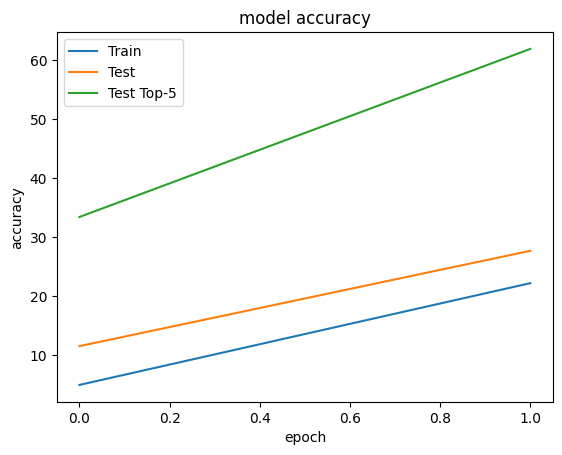

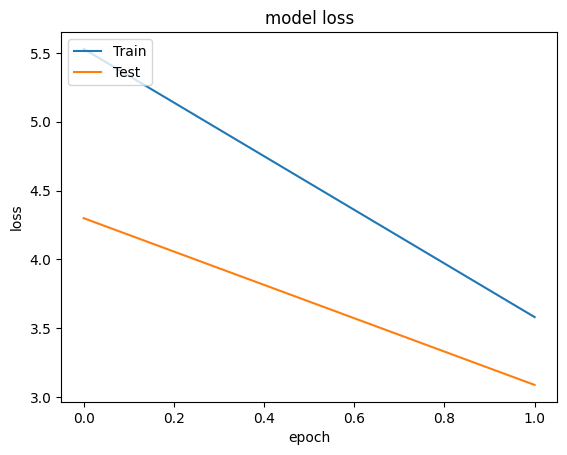

In [50]:

def create_train_dependencies():
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=config_file['lr'])
    scheduler = lr_scheduler.StepLR(optimizer, step_size=config_file['step_size'], gamma=config_file['gamma']) ## CosineAnnealingLR Dene
    return criterion, optimizer, scheduler

def train_model():
    criterion, optimizer, scheduler = create_train_dependencies()

    print(f"lr {config_file['lr']}, step_size: {config_file['step_size']}, gamma: {config_file['gamma']}, weight_decay: {config_file['weight_decay']}")
    print(f"Model hidden_dim {config_file['hidden_dim']}, num_layers: {config_file['num_layers']}")
    print(f"batch_size {config_file['batch_size']}, frame_frequency: {config_file['frame_frequency']}")

    avg_loss_list = []
    avg_accuracy_list = []
    avg_test_accuracy_list = []
    avg_top5_test_accuracy_list = []
    avg_test_loss_list = []

    num_epoch = config_file['num_epoch']
    for epoch in range(1, num_epoch+1):
        loop = tqdm(train_loader)
        running_loss = 0.0
        running_accuracy= 0.0
        for idx, (features, labels) in enumerate(loop):
            features = features.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(features)
            loss = criterion(outputs, labels)

            predictions = outputs.argmax(dim=1, keepdim=True).squeeze()
            correct = (predictions == labels).sum().item()
            accuracy = correct / len(labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            running_accuracy += 100 * accuracy
            loop.set_description(f"Epoch [{epoch}/{num_epoch}]")
            loop.set_postfix(loss=loss.item(), acc=accuracy)
        scheduler.step()
        avg_loss = running_loss / len(train_loader)
        avg_accuracy = running_accuracy / len(train_loader)
        print(f"Time: {get_current_time()} Epoch [{epoch}], Avg loss: {avg_loss:.4f}, Avg accuracy: {avg_accuracy:.4f}")
        avg_test_accuracy, avg_top5_test_accuracy, avg_test_loss = test_model(model, criterion)

        avg_loss_list.append(avg_loss)
        avg_accuracy_list.append(avg_accuracy)
        avg_test_accuracy_list.append(avg_test_accuracy)
        avg_top5_test_accuracy_list.append(avg_top5_test_accuracy)
        avg_test_loss_list.append(avg_test_loss)

    plot_result(avg_accuracy_list, avg_test_accuracy_list, avg_top5_test_accuracy_list, avg_loss_list, avg_test_loss_list)
    current_time = get_current_time()
    save_model_result(model, current_time, avg_accuracy_list, avg_test_accuracy_list, avg_top5_test_accuracy_list, avg_loss_list, avg_test_loss_list)
train_model()

In [49]:
import matplotlib.pyplot as plt
import torch
def plot_result(avg_accuracy_list, avg_test_accuracy_list, avg_top5_test_accuracy_list, avg_loss_list, avg_test_loss_list):
    # summarize history for accuracy
    plt.plot(avg_accuracy_list) 
    plt.plot(avg_test_accuracy_list)
    plt.plot(avg_top5_test_accuracy_list)
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['Train', 'Test', 'Test Top-5'], loc='upper left')
    plt.show()
    # summarize history for loss
    plt.plot(avg_loss_list)
    plt.plot(avg_test_loss_list)
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['Train', 'Test'], loc='upper left')
    plt.show()